<a href="https://colab.research.google.com/github/fyseo/traffic-vision-yolo/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project: Road Object Detection

Detecting road users and traffic objects across diverse driving scenes with the pretrained YOLO11 Nano model.

### Project Sections
* **Section A:** Static image analysis and raw dataset exploration.
* **Section B:** Frame-by-frame batch inference over recorded intersection video footage.
* **Section C:** Real-time stream processing from a live camera feed.

## 1. Environment Setup & Data Installation
Install the required packages, authenticate the Kaggle API, and acquire the datasets for testing. We use a BDD100K Kaggle dataset for static images (Scenario A) and load a local video file for video processing (Scenario B).


In [1]:
# Install core dependencies
%pip install ultralytics opencv-python matplotlib kaggle

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

# --- SCENARIO A: STATIC BDD100K IMAGES ---
# Kaggle mirror: about 5.86 GB; this downloads the full dataset.
print("Downloading BDD100K YOLO-format dataset...")
!python -m kaggle datasets download -d shuvoalok/dawn-dataset -p dataset/ --unzip

# --- SCENARIO B: VIDEO DATASET ---
# Loading a sample video directly from the local project files
video_file_path = "road_traffic.mp4"

Dataset URL: https://www.kaggle.com/datasets/shuvoalok/dawn-dataset
License(s): CC-BY-NC-SA-4.0




  0%|          | 0.00/132M [00:00<?, ?B/s]
  1%|          | 1.00M/132M [00:01<02:54, 790kB/s]
  2%|▏         | 2.00M/132M [00:02<02:39, 857kB/s]
  2%|▏         | 3.00M/132M [00:03<02:33, 884kB/s]
  3%|▎         | 4.00M/132M [00:04<02:36, 862kB/s]
  4%|▍         | 5.00M/132M [00:05<02:29, 893kB/s]
  5%|▍         | 6.00M/132M [00:06<02:15, 977kB/s]
  5%|▌         | 7.00M/132M [00:08<02:19, 942kB/s]
  6%|▌         | 8.00M/132M [00:10<02:54, 745kB/s]
  7%|▋         | 9.00M/132M [00:11<02:41, 799kB/s]
  8%|▊         | 10.0M/132M [00:12<02:36, 818kB/s]
  8%|▊         | 11.0M/132M [00:13<02:30, 842kB/s]
  9%|▉         | 12.0M/132M [00:14<02:22, 884kB/s]
 10%|▉         | 13.0M/132M [00:15<02:08, 975kB/s]
 11%|█         | 14.0M/132M [00:16<01:52, 1.10MB/s]
 11%|█▏        | 15.0M/132M [00:16<01:46, 1.15MB/s]
 12%|█▏        | 16.0M/132M [00:17<01:44, 1.17MB/s]
 13%|█▎        | 17.0M/132M [00:18<01:43, 1.16MB/s]
 14%|█▎        | 18.0M/132M [00:19<01:37, 1.23MB/s]
 14%|█▍        | 19.0M/132M [00:2

## 2. Imports & Model Loading
Initialize the computer vision libraries and load the pre-trained model into memory once to save overhead during inference. We utilize YOLO11 Nano (`yolo11n.pt`) as it offers the best balance of accuracy and real-time processing speeds.

In [3]:
from ultralytics import YOLO
import cv2
import numpy as np
import glob
import random
import matplotlib.pyplot as plt

In [4]:
# Load the YOLO11 Nano model
model = YOLO("yolo11n.pt") 
print(f"Model successfully loaded. Classes available: {model.names}")

Model successfully loaded. Classes available: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote',

## 3. Scenario A: Static Image Object Detection
In this scenario, we evaluate the pre-trained YOLO11 model on static images from the downloaded vehicle dataset:
1. **Data Exploration:** Collect all image paths and sample random images to visualize raw, untouched inputs.
2. **Inference & Detection:** Run detection on each sampled image using the bounding box and annotation pipeline, displaying the detected classes, confidence scores, and object counts.

Total images found in dataset: 1027


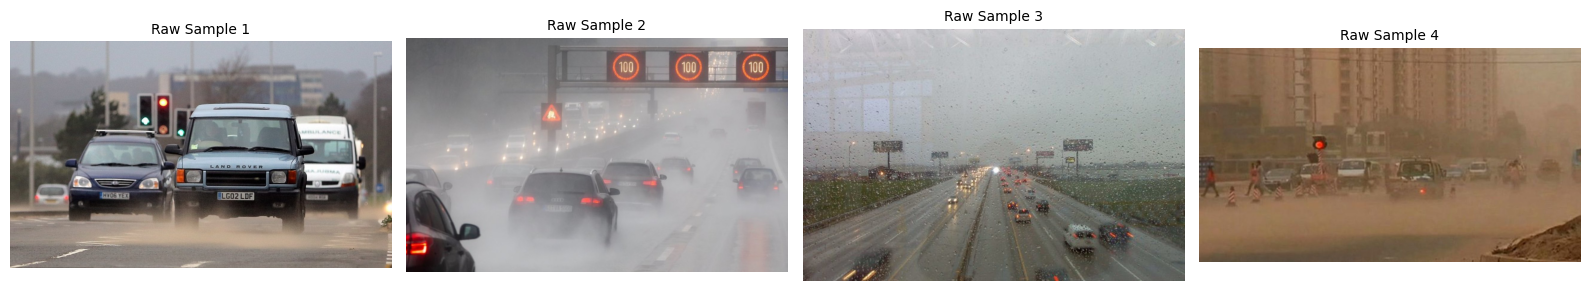

In [8]:
# Gather all image files from the extracted dataset directory
all_image_paths = []
all_image_paths.extend(glob.glob(f"dataset/**/{"*.jpg"}", recursive=True))

print(f"Total images found in dataset: {len(all_image_paths)}")

# Random samples of dataset images
num_samples = 4
sampled_image_paths = np.random.choice(all_image_paths, size=num_samples, replace=False)

# Visualize raw images before any detection
plt.figure(figsize=(16, 4))
for idx, img_path in enumerate(sampled_image_paths):
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, num_samples, idx + 1)
    plt.imshow(img_rgb)
    plt.title(f"Raw Sample {idx + 1}", fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

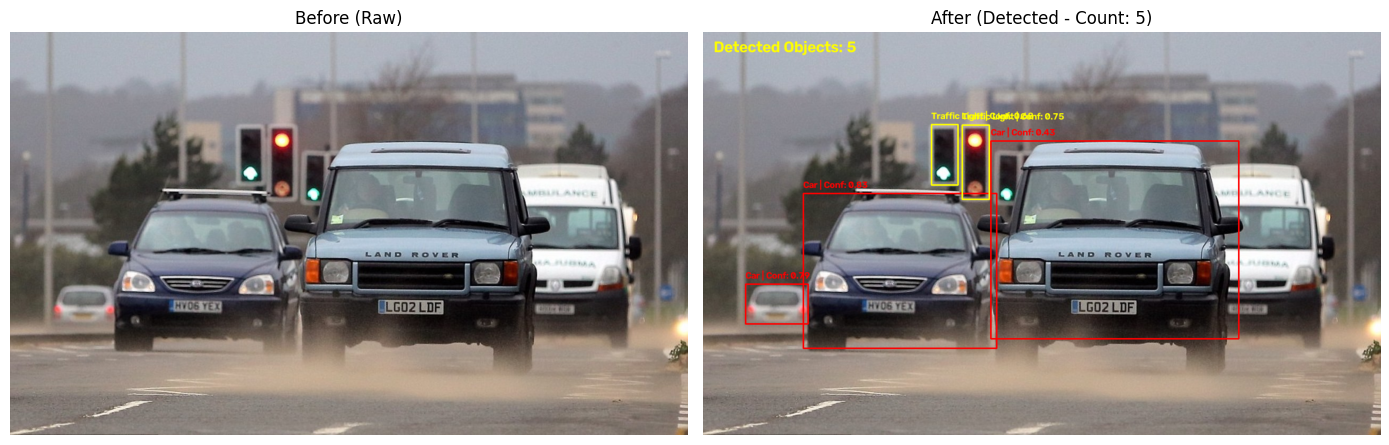

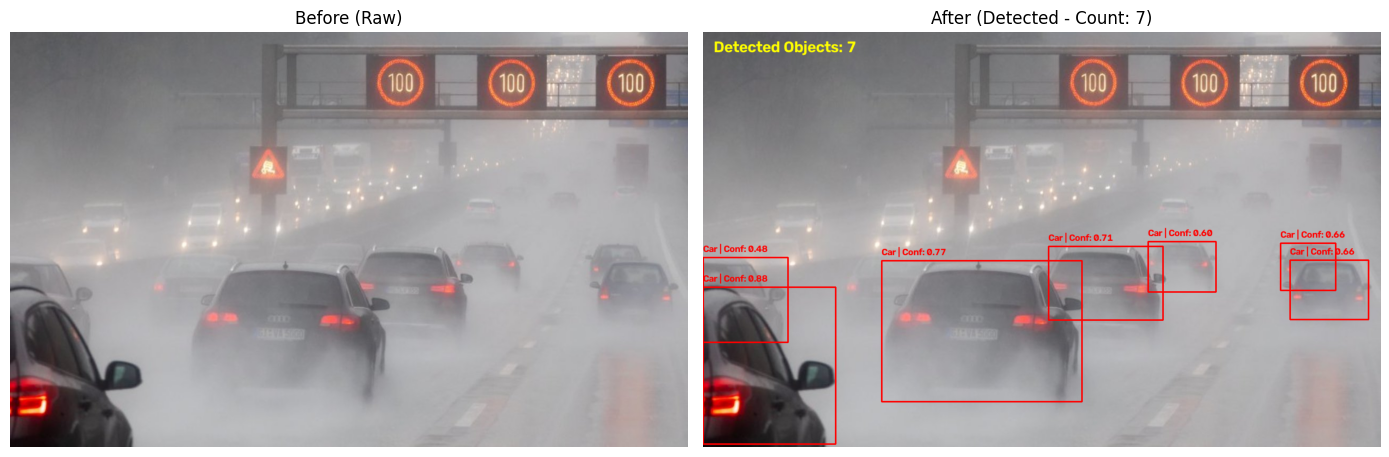

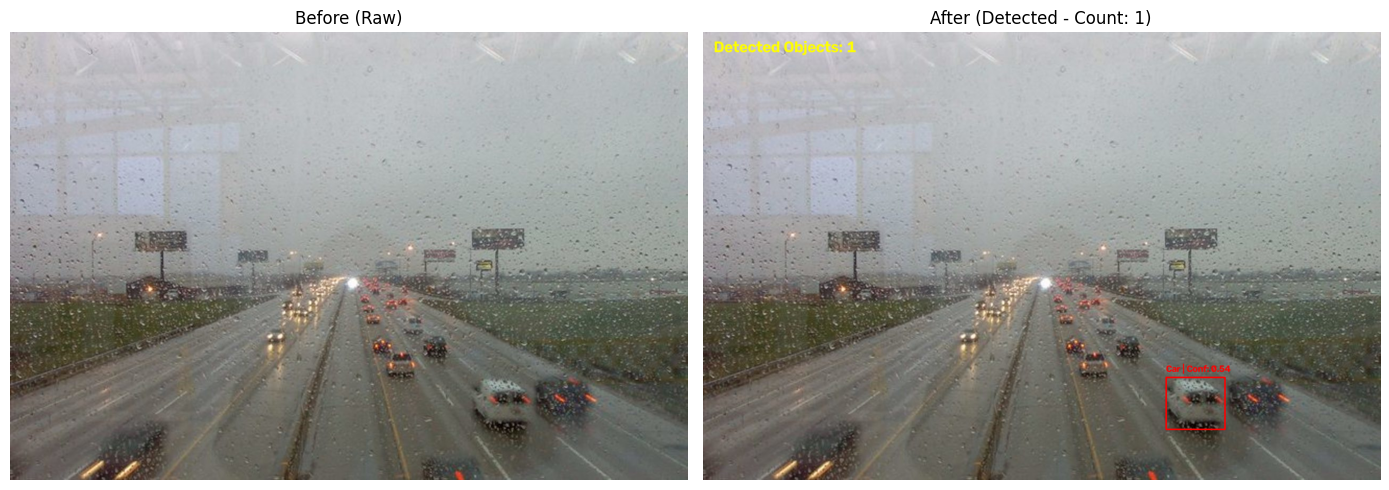

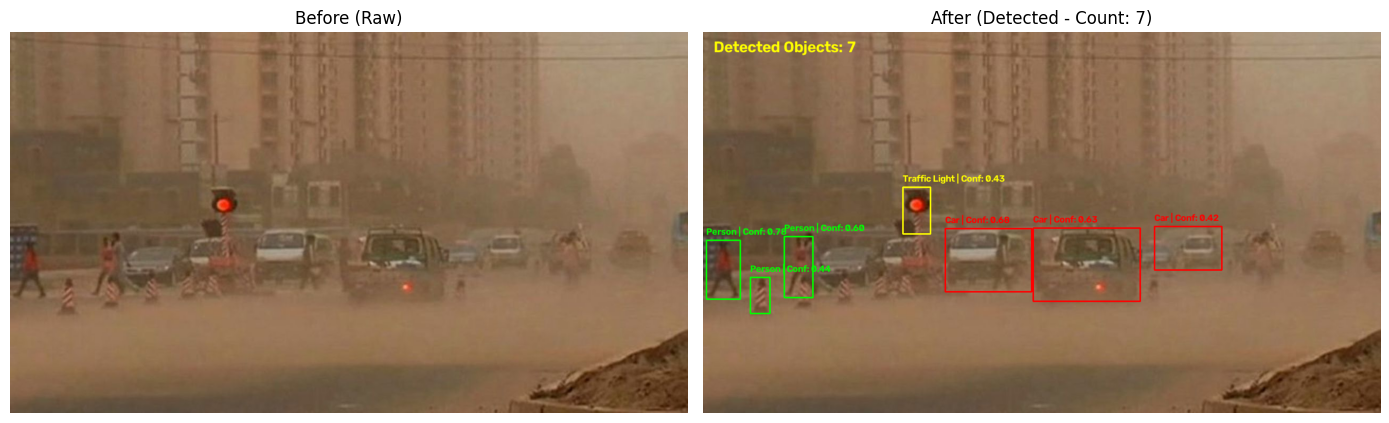

In [9]:
# Target traffic/intersection classes from COCO (classes present in model.names)
target_classes = {
    0: "Person",
    1: "Bicycle",
    2: "Car",
    3: "Motorcycle",
    5: "Bus",
    7: "Truck",
    9: "Traffic Light",
    11: "Stop Sign",
    32: "Sports Ball"
}

# Run detection and display results following the lab's annotation loop
for idx, img_path in enumerate(sampled_image_paths):
    frame_raw = cv2.imread(img_path)
    frame_annotated = frame_raw.copy()
    
    # Run YOLO11 prediction
    results = model.predict(source=frame_annotated, conf=0.4, verbose=False)
    
    detected_count = 0
    for r in results:
        for box, cls, conf in zip(r.boxes.xyxy, r.boxes.cls, r.boxes.conf):
            cls_id = int(cls)
            confidence = float(conf)
            
            # Check if detected object is among target traffic classes
            if cls_id in target_classes:
                detected_count += 1
                x1, y1, x2, y2 = map(int, box)
                label = f"{target_classes[cls_id]} | Conf: {confidence:.2f}"
                
                # Distinct bounding box colors by category
                if cls_id in [2, 7]:      # Car / Truck
                    color = (0, 0, 255)   # Red (BGR)
                elif cls_id in [1, 3, 5]:  # Bicycle / Motorcycle / Bus
                    color = (255, 0, 0)   # Blue (BGR)
                elif cls_id == 0:         # Person
                    color = (0, 255, 0)   # Green (BGR)
                else:
                    color = (0, 255, 255) # Yellow (BGR)
                
                # Draw bounding box and label
                cv2.rectangle(frame_annotated, (x1, y1), (x2, y2), color, 2)
                cv2.putText(frame_annotated, label, (x1, max(y1 - 10, 20)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    
    # Overlay total detected count in top-left corner (from the lab structure)
    cv2.putText(frame_annotated, f"Detected Objects: {detected_count}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)
    
    # Display Before vs After side-by-side using matplotlib
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].imshow(cv2.cvtColor(frame_raw, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Before (Raw)")
    axes[0].axis("off")
    
    axes[1].imshow(cv2.cvtColor(frame_annotated, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"After (Detected - Count: {detected_count})")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

## 4. Scenario B: Pre-Recorded Video Processing
Process a local traffic video (`road_traffic.mp4`) frame-by-frame. The YOLO11 model detects vehicles and pedestrians, draws bounding boxes, and writes the annotated frames out to a new video file (`video_output.mp4`).

In [ ]:
# CHECK BEFORE U RUN_________________________________-----------------
# --- SCENARIO B: VIDEO DATASET ---
# Note: 'model' and 'target_classes' are carried over from Section 3.

video_in_path = "13652085_960_540_60fps.mp4" #test change later
video_out_path = "video_output.mp4"

if not os.path.exists(video_in_path):
    print(f"Error: '{video_in_path}' not found in the workspace.")
else:
    cap = cv2.VideoCapture(video_in_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    out = cv2.VideoWriter(video_out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))

    print(f"Processing video: {width}x{height} at {fps} FPS ({total_frames} frames total)...")

    # Placeholder to store one processed frame for notebook visualization
    sample_frame_to_show = None

    frame_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        frame_count += 1

        # Run YOLO11 detection
        results = model.predict(source=frame, conf=0.4, verbose=False)

        detected_objects = 0
        for r in results:
            for box, cls, conf in zip(r.boxes.xyxy, r.boxes.cls, r.boxes.conf):
                cls_id = int(cls)
                confidence = float(conf)

                # Check if detected object is among target traffic classes
                if cls_id in target_classes:
                    detected_objects += 1
                    x1, y1, x2, y2 = map(int, box)
                    label = f"{target_classes[cls_id]} | Conf: {confidence:.2f}"

                    # Distinct bounding box colors by category
                    if cls_id in [2, 7]:       # Car / Truck
                        color = (0, 0, 255)    # Red
                    elif cls_id in [1, 3, 5]:  # Bicycle / Motorcycle / Bus
                        color = (255, 0, 0)    # Blue
                    elif cls_id == 0:          # Person
                        color = (0, 255, 0)    # Green
                    else:
                        color = (0, 255, 255)  # Yellow

                    # Draw bounding box and label
                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                    cv2.putText(frame, label, (x1, max(y1 - 10, 20)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        
        # Display detection count and frame progress
        cv2.putText(frame, f"Objects: {detected_objects} | Frame: {frame_count}/{total_frames}", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)

        out.write(frame)
        
        # Capture a frame from the middle of the video to showcase in the notebook
        if frame_count == total_frames // 2:
            sample_frame_to_show = frame.copy()

    cap.release()
    out.release()
    print(f"Video processing complete! Saved to {video_out_path}")

    # Visualize the sample frame inline for presentation purposes
    if sample_frame_to_show is not None:
        plt.figure(figsize=(12, 6))
        plt.imshow(cv2.cvtColor(sample_frame_to_show, cv2.COLOR_BGR2RGB))
        plt.title(f"Sample Annotated Frame (Frame {total_frames // 2})")
        plt.axis("off")
        plt.show()

from IPython.display import Video, display

display(Video(video_out_path, embed=True, html_attributes="controls"))

In [ ]:

# maybe this wont be from a random sample just a set video or two, decide on that later
cap = cv2.VideoCapture("road_traffic.mp4")
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25

out = cv2.VideoWriter("video_output.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))



while True:
    ret, frame = cap.read()
    if not ret:
        break


    # detection
    results = model(frame, verbose=False)

    for box in results[0].boxes:
        cls_id = int(box.cls[0])
        label = model.names[cls_id]
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        if label == "car":
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 0, 255), 1)
            cv2.putText(frame, f"{label} {conf:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 1)
        if label == "bus":
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 1)
            cv2.putText(frame, f"{label} {conf:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 1)
        if label == "motorcycle":
            cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 1)
            cv2.putText(frame, f"{label} {conf:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 1)
        if label == "person":
            cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 255, 0), 1)
            cv2.putText(frame, f"{label} {conf:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 1)

    out.write(frame)

cap.release()
out.release()

## 5. Scenario C: Live Camera Inference
Run real-time object detection using the local machine's webcam. A window will open displaying the live feed with bounding boxes and class labels. **Press the 'q' key** while the window is active to safely terminate the stream and release the camera.

In [ ]:
# CHECK BEFORE U RUN_________________________________-----------------
# --- SCENARIO C: LIVE CAMERA FEED ---
# Note: 'model' and 'target_classes' are carried over from Section 3.

# 0 is the default ID for the built-in webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open the webcam. Check your privacy settings or camera index.")
else:
    print("Starting live feed... Click the video window and press 'q' to quit.")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame.")
            break
            
        # Run YOLO11 detection
        results = model.predict(source=frame, conf=0.4, verbose=False)
        
        detected_count = 0
        for r in results:
            for box, cls, conf in zip(r.boxes.xyxy, r.boxes.cls, r.boxes.conf):
                cls_id = int(cls)
                confidence = float(conf)
                
                # Filter by intersection/traffic classes
                if cls_id in target_classes:
                    detected_count += 1
                    x1, y1, x2, y2 = map(int, box)
                    label = f"{target_classes[cls_id]} | Conf: {confidence:.2f}"
                    
                    # Distinct bounding box colors # add it so that for this live feed it displayes different colors for different classes not only these 4
                    if cls_id in [2, 7]:       # Car / Truck
                        color = (0, 0, 255)    # Red
                    elif cls_id in [1, 3, 5]:  # Bicycle / Motorcycle / Bus
                        color = (255, 0, 0)    # Blue
                    elif cls_id == 0:          # Person
                        color = (0, 255, 0)    # Green
                    elif cls_id == 32:          # Sports Ball
                        color = (255, 0, 255)  # Magenta
                    else:
                        color = (0, 255, 255)  # Yellow
                        
                    # Draw bounding box and label
                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                    cv2.putText(frame, label, (x1, max(y1 - 10, 20)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        
        # Display detection count in the corner
        cv2.putText(frame, f"Live Objects: {detected_count}", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)
        
        # Render the live window
        cv2.imshow("Live Intersection Detection", frame)
        
        # Break the loop if 'q' is pressed
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Clean up the camera and close the window safely
    cap.release()
    cv2.destroyAllWindows()
    print("Live feed terminated safely.")

Starting live feed... Click the video window and press 'q' to quit.
Live feed terminated safely.
